In [106]:
import pandas as pd
import numpy as np
import re
from scipy.stats import ttest_rel, wilcoxon
from scipy.stats import f_oneway
import seaborn as sns
import matplotlib.pyplot as plt

# Load Recommendations

In [107]:
playlist_recommendation = pd.read_csv("/Users/ohungchan/Downloads/recommendations_for_all_models.csv")

In [108]:
def convert_string_array_to_list(s):
    """Convert a string representation of an array into a list of integers."""
    if isinstance(s, str):  # Handle string case (where it's incorrectly stored)
        numbers = re.findall(r'\d+', s)  # Extract all numeric values
        return [int(x) for x in numbers]  # Convert to integers
    
    elif isinstance(s, np.ndarray):  # Handle NumPy array case
        return s.astype(int).tolist()
    
    elif isinstance(s, list):  # Handle lists with possible string numbers
        return [int(x) for x in s if str(x).isdigit()]
    
    return []  # Return empty list if the format is unexpected

# Apply function and debug output
playlist_recommendation['tracks_to_predict'] = playlist_recommendation['tracks_to_predict'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['random_recommendations'] = playlist_recommendation['random_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_unweigted_recommendations'] = playlist_recommendation['content_based_unweigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['content_based_weigted_recommendations'] = playlist_recommendation['content_based_weigted_recommendations'].apply(lambda x: convert_string_array_to_list(x))
playlist_recommendation['collaborative_filtering_recommendations'] = playlist_recommendation['collaborative_filtering_recommendations'].apply(lambda x: convert_string_array_to_list(x))

playlist_recommendation.head()

,playlist_idx,cluster,tracks_to_predict,random_recommendations,collaborative_filtering_recommendations,content_based_unweigted_recommendations,content_based_weigted_recommendations
0,2,3,"[232845, 111887, 144160, 10663, 216321, 138869...","[174804, 45667, 180239, 72464, 155677, 131180,...","[174997, 175642, 186858, 72522, 111887, 55648,...","[26657, 102881, 169451, 97130, 76387, 177055, ...","[44021, 153676, 129186, 58351, 130032, 135471,..."
1,7,1,"[48557, 142203, 66610, 16213, 112277, 43008, 2...","[205630, 246877, 130193, 36681, 90295, 118324,...","[191313, 111863, 163571, 89133, 216260, 237774...","[121753, 168149, 245519, 129186, 140469, 10137...","[102680, 129186, 147304, 60873, 229551, 194684..."
2,10,0,"[89301, 74022, 221104, 218307, 229795, 129045,...","[123988, 154415, 107915, 207660, 19850, 7725, ...","[208248, 94251, 218307, 122853, 212881, 221104...","[137497, 208248, 83517, 3939, 26659, 234445, 6...","[208248, 232281, 144800, 240182, 44263, 63352,..."
3,17,2,"[131069, 102197, 241039, 46103, 41621, 213083,...","[117021, 227150, 234857, 240503, 162330, 37045...","[235367, 216374, 237415, 64550, 250306, 140314...","[237818, 208248, 156298, 237495, 194633, 25030...","[237818, 123797, 237495, 156298, 31218, 149917..."
4,28,2,"[166174, 63352, 37636, 75383, 195511, 131429, ...","[234157, 246389, 216575, 93478, 6884, 97278, 3...","[250306, 26659, 86790, 167186, 180201, 64550, ...","[29052, 26659, 251276, 208248, 234445, 250306,...","[26659, 234445, 251276, 250306, 245084, 29052,..."


# Code for Evaluation

For the base models, we will first use accuracy metrics for evaluation. 

  - **Hit Ratio @K:** Fraction of playlists with at least one test track in the top K.
  - **MRR:** Average reciprocal rank of the first relevant test track.
  - **MAP @K:** Mean average precision over the top K recommendations.

The reason for using accuracy metrics for now is as follows

  - It is necessary that our model still recommends tracks that the user would actually be listening to (tracks_to_predict)
  - It shows that our feature engineering has been effective
  - It provides an objective measurement of the models


In later stages of model development, we will transition to behavioural metrics by using Relevance, Diversity, Serendipity for evaluating the performance, as it would be more closely aligned with our business objective.

**All of the test here are conducted on the 'Test' set, which have not been involved in the training process. We also have another 'Final Test' set which we will do the final evaluation of our model's performance later on.** 

In [109]:
def compute_metrics_for_playlist(predicted_tracks, test_indices, k):
    top_k = predicted_tracks[:k]  # Consider only top K predictions

    # Hit@K
    hit = int(any(t in top_k for t in test_indices))

    # MRR and AP calculations
    precisions = []
    num_hits = 0
    mrr = 0.0

    for rank_idx, track_idx in enumerate(top_k):
        if track_idx in test_indices:
            num_hits += 1
            precision_at_k = num_hits / (rank_idx + 1)
            precisions.append(precision_at_k)
            if mrr == 0.0:
                mrr = 1.0 / (rank_idx + 1)

    ap = np.mean(precisions) if precisions else 0.0

    return hit, mrr, ap

def evaluate_model(playlist, column_name, k):
    num_playlists = len(playlist)

    hit_total, mrr_total, ap_total = 0, 0, 0

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hit_total += hit
        mrr_total += mrr
        ap_total += ap

    # Compute averages
    hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
    mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
    map_avg = ap_total / num_playlists if num_playlists > 0 else 0

    return hit_ratio, mrr_avg, map_avg, column_name

def evaluate_model_hypo(playlist, column_name, k, return_all=False):
    hits, mrrs, aps = [], [], []

    for idx, row in playlist.iterrows():
        test_indices = row['tracks_to_predict']
        predicted_tracks = row[column_name]

        hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
        
        hits.append(hit)
        mrrs.append(mrr)
        aps.append(ap)

    if return_all:
        return hits, mrrs, aps  # return lists for paired testing
    else:
        num_playlists = len(hits)
        hit_ratio = sum(hits) / num_playlists if num_playlists > 0 else 0
        mrr_avg = sum(mrrs) / num_playlists if num_playlists > 0 else 0
        map_avg = sum(aps) / num_playlists if num_playlists > 0 else 0
        return hit_ratio, mrr_avg, map_avg, column_name

def compare_models(playlist, model_a_col, model_b_col, k):
    # Get per-playlist metrics
    hits_a, mrrs_a, aps_a = evaluate_model_hypo(playlist, model_a_col, k, return_all=True)
    hits_b, mrrs_b, aps_b = evaluate_model_hypo(playlist, model_b_col, k, return_all=True)

    # Paired t-tests
    t_hit, p_hit = ttest_rel(hits_a, hits_b)
    t_mrr, p_mrr = ttest_rel(mrrs_a, mrrs_b)
    t_ap, p_ap = ttest_rel(aps_a, aps_b)

    return {
        "Hit@K": {"t-stat": t_hit, "p-value": p_hit},
        "MRR": {"t-stat": t_mrr, "p-value": p_mrr},
        "MAP": {"t-stat": t_ap, "p-value": p_ap}
    }

def evaluate_model_by_cluster(playlist, column_name, k, cluster_column):
    # Group by the cluster column
    clusters = playlist.groupby(cluster_column)
    
    cluster_metrics = {}

    for cluster, cluster_data in clusters:
        # Initialize total metrics for the current cluster
        hit_total, mrr_total, ap_total = 0, 0, 0

        for idx, row in cluster_data.iterrows():
            test_indices = row['tracks_to_predict']
            predicted_tracks = row[column_name]

            hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)

            hit_total += hit
            mrr_total += mrr
            ap_total += ap

        # Compute averages for the current cluster
        num_playlists = len(cluster_data)
        hit_ratio = hit_total / num_playlists if num_playlists > 0 else 0
        mrr_avg = mrr_total / num_playlists if num_playlists > 0 else 0
        map_avg = ap_total / num_playlists if num_playlists > 0 else 0

        # Store the metrics for the current cluster
        cluster_metrics[cluster] = {
            "Hit@K": hit_ratio,
            "MRR": mrr_avg,
            "MAP": map_avg
        }

    return cluster_metrics

def evaluate_row_metrics(row, column_name, k):
    test_indices = row['tracks_to_predict']
    predicted_tracks = row[column_name]

    hit, mrr, ap = compute_metrics_for_playlist(predicted_tracks, test_indices, k)
    
    return hit, mrr, ap

def create_metrics_dataframe(playlist, column_name, k, cluster_column):
    # Apply the evaluate_row_metrics function to each row
    metrics = playlist.apply(lambda row: evaluate_row_metrics(row, column_name, k), axis=1)
    
    # Create a new dataframe with the metrics
    metrics_df = pd.DataFrame(metrics.tolist(), columns=["Hit@K", "MRR", "MAP"])
    metrics_df[cluster_column] = playlist[cluster_column].values  # Add the cluster information

    return metrics_df

def perform_f_test_on_metrics(metrics_df, cluster_column):
    # Group the data by the cluster column
    grouped = metrics_df.groupby(cluster_column)

    # Prepare lists to store values for each metric
    hit_values = []
    mrr_values = []
    ap_values = []
    
    for cluster, group in grouped:
        hit_values.append(group["Hit@K"].values)
        mrr_values.append(group["MRR"].values)
        ap_values.append(group["MAP"].values)

    # Perform F-tests (ANOVA) for each metric
    try:
        f_hit, p_hit = f_oneway(*hit_values)
        f_mrr, p_mrr = f_oneway(*mrr_values)
        f_ap, p_ap = f_oneway(*ap_values)

        # Print the results of the F-tests
        results = {
            "Hit@K": {"F-stat": f_hit, "p-value": p_hit},
            "MRR": {"F-stat": f_mrr, "p-value": p_mrr},
            "MAP": {"F-stat": f_ap, "p-value": p_ap}
        }

        for metric, res in results.items():
            f_stat = res['F-stat']
            p_val = res['p-value']

            print(f"\n=== {metric} F-test ===")
            print(f"F-statistic: {f_stat:.3f}")
            print(f"p-value: {p_val:.4f}")
            if p_val < 0.05:
                print("There is a significant difference between the clusters for this metric.")
            else:
                print("There is no significant difference between the clusters for this metric.")
    except ValueError as e:
        print(f"Error performing F-test: {e}. Possibly due to insufficient data in one or more clusters.")

# Level 1: Comparing Content Based Model & Collaborative Filtering against Random Model

## Model Performance

Random Model

In [110]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'random_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for random_recommendations
Hit@50: 0.0032
MRR: 0.0001
MAP@50: 0.0001


Content Based Model

In [111]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_unweigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_unweigted_recommendations
Hit@50: 0.3582
MRR: 0.0757
MAP@50: 0.0613


Collaborative Filtering

In [112]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'collaborative_filtering_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for collaborative_filtering_recommendations
Hit@50: 0.5673
MRR: 0.1372
MAP@50: 0.0982


## Random Model vs Content Based

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{random}} \ge \mu_{\text{content based}} \quad \text{(Random performs at least as well as content based)} \\
H_1 &: \mu_{\text{random}} < \mu_{\text{content based}} \quad \text{(Content based performs better than random)}
\end{aligned}

In [113]:
results = compare_models(
    playlist_recommendation,
    "random_recommendations",
    "content_based_unweigted_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Random Model vs Content Based")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Random Model vs Content Based

=== Hit@K Comparison ===
t-statistic: -31.682
one-sided p-value: 0.0000

=== MRR Comparison ===
t-statistic: -16.119
one-sided p-value: 0.0000

=== MAP Comparison ===
t-statistic: -16.539
one-sided p-value: 0.0000


## Random Model vs Collaborative Filtering

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{random}} \ge \mu_{\text{collaborative filtering}} \quad \text{(Random performs at least as well as collaborative filtering)} \\
H_1 &: \mu_{\text{random}} < \mu_{\text{collaborative filtering}} \quad \text{(Collaborative filtering performs better than random)}
\end{aligned}

In [114]:
results = compare_models(
    playlist_recommendation,
    "random_recommendations",
    "collaborative_filtering_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Random Model vs Collaborative Filtering")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Random Model vs Collaborative Filtering

=== Hit@K Comparison ===
t-statistic: -48.497
one-sided p-value: 0.0000

=== MRR Comparison ===
t-statistic: -22.574
one-sided p-value: 0.0000

=== MAP Comparison ===
t-statistic: -24.984
one-sided p-value: 0.0000


## Conclusion

Since both the p-values for the hypothesis testing is almost 0, we have sufficient evidence to reject the null hypothesis, and conclude that both content based and collaborative filtering performs signficantly better than the random model.

This shows that the base models that we have is better than a random guess, and our feature engineering has been effective.

We will continue to use our base models.

# Level 2: Comparing Content Based Model between Weighted vs Unweighted Tracks

Previously, we have hypothesized that the tracks that were present in the playlist at a higher index could have been added more recently, and thus is a better reflection of the user's taste and preference. 

During our playlist feature engineering, we have assigned different weights to each tracks based on num_edit and num_tracks. 

We thus have 2 sets of playlist features. One for the weighted tracks, and the other for the unweighted tracks. 

We will aim to find out whether there is a significant difference in the accuracy of prediction of the tracks that were hidden, given the same tracks to predict.

## Model Performance

Weighted Tracks

In [115]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_weigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_weigted_recommendations
Hit@50: 0.3420
MRR: 0.0796
MAP@50: 0.0618


Unweighted Tracks

In [116]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_unweigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_unweigted_recommendations
Hit@50: 0.3582
MRR: 0.0757
MAP@50: 0.0613


## Unweighted Tracks vs Weighted Tracks

We will conduct a one-sided paired 2-sample hypothesis test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{unweighted tracks}} \ge \mu_{\text{weighted tracks}} \quad \text{(Unweighted tracks performs at least as well as Weighted tracks)} \\
H_1 &: \mu_{\text{unweighted tracks}} < \mu_{\text{weighted tracks}} \quad \text{(Weighted tracks performs better than Unweighted tracks)}
\end{aligned}

In [117]:
results = compare_models(
    playlist_recommendation,
    "content_based_unweigted_recommendations",
    "content_based_weigted_recommendations",
    k=50
)

alpha = 0.05  # significance level

print("Hypothesis Test between Unweighted Tracks vs Weighted Tracks")

for metric, res in results.items():
    t_stat = res['t-stat']
    two_sided_p_val = res['p-value']
    one_sided_p_val = two_sided_p_val / 2

    print(f"\n=== {metric} Comparison ===")
    print(f"t-statistic: {t_stat:.3f}")
    print(f"one-sided p-value: {one_sided_p_val:.4f}")

Hypothesis Test between Unweighted Tracks vs Weighted Tracks

=== Hit@K Comparison ===
t-statistic: 1.891
one-sided p-value: 0.0294

=== MRR Comparison ===
t-statistic: -0.932
one-sided p-value: 0.1758

=== MAP Comparison ===
t-statistic: -0.123
one-sided p-value: 0.4510


## Conclusion

For the Hit@K metrics, the p-value is < 0.05, which suggests that the weighted tracks perform better than the unweighted tracks.

However, for the other 2 metrics, the p-value is > 0.05, suggesting that the unweighted tracks performs at least as well as the weighted tracks.

There is not a strong enough evidence for us to carry on with the assumption that the more recent tracks are more reflective, and makes the model perform better.

As such, we will continue using the playlist that has the tracks as unweighted due to the many assumptions that we would have to make in order to use the weighted tracks. 

# Level 3: Comparing between Content Based and Collaborative Filtering

## Model Performance

Content Based Model

In [118]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'content_based_unweigted_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for content_based_unweigted_recommendations
Hit@50: 0.3582
MRR: 0.0757
MAP@50: 0.0613


Collaborative Filtering

In [119]:
# Run evaluation
hit_ratio, mrr_avg, map_avg, column_name = evaluate_model(playlist_recommendation, 'collaborative_filtering_recommendations', k=50)

# Print results
print(f"Evaluation Metrics for {column_name}")
print(f"Hit@50: {hit_ratio:.4f}")
print(f"MRR: {mrr_avg:.4f}")
print(f"MAP@50: {map_avg:.4f}")

Evaluation Metrics for collaborative_filtering_recommendations
Hit@50: 0.5673
MRR: 0.1372
MAP@50: 0.0982


Although the collaborative filtering seems to perform better than the content based model, we will do a deeper analysis on whether it is the case for each cluster.

We will also try to find out the pros and cons of each model.

## Comparing Across Different Playlist Clusters

As we have segmented the playlist into 4 clusters previously, we will conduct a F-Test to check whether there are any statistical difference in the performance across the different clusters.

This will prove whether the segmentation is meaningful for further analysis.

### Content Based Model

In [120]:
# Assuming 'cluster_column' is the column with cluster labels
cluster_metrics = evaluate_model_by_cluster(playlist_recommendation, "content_based_unweigted_recommendations", k=50, cluster_column="cluster")

print("Evaluation Metrics for Content Based\n")

# Print the metrics for each cluster
for cluster, metrics in cluster_metrics.items():
    print(f"Metrics for Cluster {cluster}:")
    print(f"Hit@K: {metrics['Hit@K']:.4f}")
    print(f"MRR: {metrics['MRR']:.4f}")
    print(f"MAP: {metrics['MAP']:.4f}")
    print()

Evaluation Metrics for Content Based

Metrics for Cluster 0:
Hit@K: 0.2000
MRR: 0.0384
MAP: 0.0362

Metrics for Cluster 1:
Hit@K: 0.4169
MRR: 0.0934
MAP: 0.0775

Metrics for Cluster 2:
Hit@K: 0.5309
MRR: 0.1172
MAP: 0.0870

Metrics for Cluster 3:
Hit@K: 0.1746
MRR: 0.0266
MAP: 0.0252



#### F-Test

We will conduct a F-test at 5% level of significance

\begin{aligned}
H_0 &: \mu_{\text{cluster 0}} = \mu_{\text{cluster 1}} = \mu_{\text{cluster 2}} = \mu_{\text{cluster 3}} \quad \text{(No significant difference in the means of the metric across clusters when using content based)} \\
H_1 &: \text{At least one } \mu_i \neq \mu_j \quad \text{for some } i \neq j \quad \text{(There is a significant difference in the means of the metric across clusters when using content based)}
\end{aligned}

In [121]:
# Create metrics dataframe
metrics_df = create_metrics_dataframe(playlist_recommendation, "content_based_unweigted_recommendations", k=50, cluster_column='cluster')

# Group the data by the cluster column
grouped = metrics_df.groupby('cluster')

# Prepare lists to store values for each metric
hit_values = []
mrr_values = []
ap_values = []

for cluster, group in grouped:
    hit_values.append(group["Hit@K"].values)
    mrr_values.append(group["MRR"].values)
    ap_values.append(group["MAP"].values)

print("F Test between clusters in Content Based")

# Perform F-tests (ANOVA) for each metric
try:
    f_hit, p_hit = f_oneway(*hit_values)
    f_mrr, p_mrr = f_oneway(*mrr_values)
    f_ap, p_ap = f_oneway(*ap_values)

    # Print the results of the F-tests
    results = {
        "Hit@K": {"F-stat": f_hit, "p-value": p_hit},
        "MRR": {"F-stat": f_mrr, "p-value": p_mrr},
        "MAP": {"F-stat": f_ap, "p-value": p_ap}
    }

    for metric, res in results.items():
        f_stat = res['F-stat']
        p_val = res['p-value']

        print(f"\n=== {metric} F-test ===")
        print(f"F-statistic: {f_stat:.3f}")
        print(f"p-value: {p_val:.4f}")
except ValueError as e:
    print(f"Error performing F-test: {e}. Possibly due to insufficient data in one or more clusters.")


F Test between clusters in Content Based

=== Hit@K F-test ===
F-statistic: 63.164
p-value: 0.0000

=== MRR F-test ===
F-statistic: 21.632
p-value: 0.0000

=== MAP F-test ===
F-statistic: 17.105
p-value: 0.0000


Since the p-value for all 3 metrics are close to 0, we reject the null hypothesis, and conclude that there is a significant difference in the metrics for each cluster.

### Collaborative Filtering

In [122]:
# Assuming 'cluster_column' is the column with cluster labels
cluster_metrics = evaluate_model_by_cluster(playlist_recommendation, "collaborative_filtering_recommendations", k=50, cluster_column="cluster")

print("Evaluation Metrics for Collaborative Filtering\n")

# Print the metrics for each cluster
for cluster, metrics in cluster_metrics.items():
    print(f"Metrics for Cluster {cluster}:")
    print(f"Hit@K: {metrics['Hit@K']:.4f}")
    print(f"MRR: {metrics['MRR']:.4f}")
    print(f"MAP: {metrics['MAP']:.4f}")
    print()

Evaluation Metrics for Collaborative Filtering

Metrics for Cluster 0:
Hit@K: 0.6118
MRR: 0.1573
MAP: 0.1216

Metrics for Cluster 1:
Hit@K: 0.6107
MRR: 0.1446
MAP: 0.1059

Metrics for Cluster 2:
Hit@K: 0.5985
MRR: 0.1574
MAP: 0.1060

Metrics for Cluster 3:
Hit@K: 0.4504
MRR: 0.0939
MAP: 0.0667



#### F-Test

\begin{aligned}
H_0 &: \mu_{\text{cluster 0}} = \mu_{\text{cluster 1}} = \mu_{\text{cluster 2}} = \mu_{\text{cluster 3}} \quad \text{(No significant difference in the means of the metric across clusters when using collaborative filtering)} \\
H_1 &: \text{At least one } \mu_i \neq \mu_j \quad \text{for some } i \neq j \quad \text{(There is a significant difference in the means of the metric across clusters when using collaborative filtering)}
\end{aligned}

In [123]:
# Create metrics dataframe
metrics_df = create_metrics_dataframe(playlist_recommendation, "collaborative_filtering_recommendations", k=50, cluster_column='cluster')

# Group the data by the cluster column
grouped = metrics_df.groupby('cluster')

# Prepare lists to store values for each metric
hit_values = []
mrr_values = []
ap_values = []

for cluster, group in grouped:
    hit_values.append(group["Hit@K"].values)
    mrr_values.append(group["MRR"].values)
    ap_values.append(group["MAP"].values)

print("F Test between clusters in Collaborative Filtering")

# Perform F-tests (ANOVA) for each metric
try:
    f_hit, p_hit = f_oneway(*hit_values)
    f_mrr, p_mrr = f_oneway(*mrr_values)
    f_ap, p_ap = f_oneway(*ap_values)

    # Print the results of the F-tests
    results = {
        "Hit@K": {"F-stat": f_hit, "p-value": p_hit},
        "MRR": {"F-stat": f_mrr, "p-value": p_mrr},
        "MAP": {"F-stat": f_ap, "p-value": p_ap}
    }

    for metric, res in results.items():
        f_stat = res['F-stat']
        p_val = res['p-value']

        print(f"\n=== {metric} F-test ===")
        print(f"F-statistic: {f_stat:.3f}")
        print(f"p-value: {p_val:.4f}")
except ValueError as e:
    print(f"Error performing F-test: {e}. Possibly due to insufficient data in one or more clusters.")


F Test between clusters in Collaborative Filtering

=== Hit@K F-test ===
F-statistic: 11.742
p-value: 0.0000

=== MRR F-test ===
F-statistic: 5.988
p-value: 0.0005

=== MAP F-test ===
F-statistic: 7.892
p-value: 0.0000


Since the p-value for all 3 metrics are close to 0, we reject the null hypothesis, and conclude that there is a significant difference in the metrics for each cluster.

We will figure out why they are different below.

### Clustered Barplot

We will first visualize the difference in the metrics for different clusters by the 2 models. 

As the trend for HitRate@K, MRR, MAP are similar (ie. for a cluster that is high in HitRate@K, it is also higher in other 2 metrics), we will only visualize the HitRate@K metrics.

/var/folders/xf/v125knts0p57cdp0hhtgh8y00000gn/T/ipykernel_5268/2575069568.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="Cluster", y="Score", hue="Model", data=melted_df, ci=None, palette="muted")


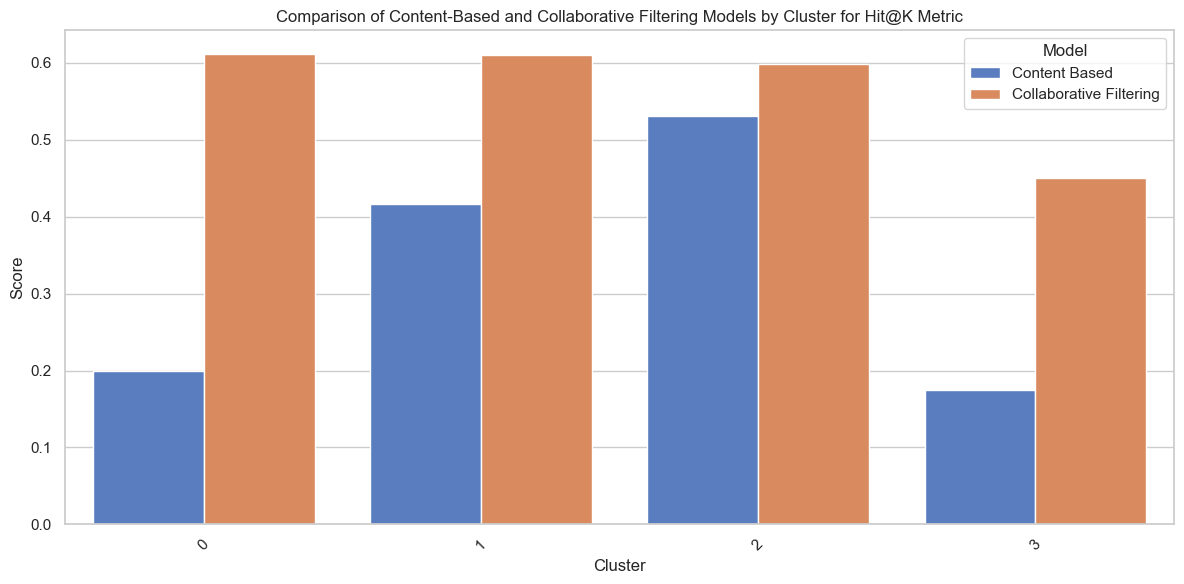

In [124]:
# Content-based model metrics
cluster_metrics_content_based = evaluate_model_by_cluster(playlist_recommendation, "content_based_unweigted_recommendations", k=50, cluster_column="cluster")

# Collaborative filtering model metrics
cluster_metrics_collaborative = evaluate_model_by_cluster(playlist_recommendation, "collaborative_filtering_recommendations", k=50, cluster_column="cluster")


# Prepare the data for visualization
content_based_metrics = []
collaborative_filtering_metrics = []

# For content-based model
for cluster, metrics in cluster_metrics_content_based.items():
    content_based_metrics.append({
        "Cluster": cluster,
        "Model": "Content Based",
        "Hit@K": metrics["Hit@K"]
    })

# For collaborative filtering model
for cluster, metrics in cluster_metrics_collaborative.items():
    collaborative_filtering_metrics.append({
        "Cluster": cluster,
        "Model": "Collaborative Filtering",
        "Hit@K": metrics["Hit@K"]
    })

# Convert the lists to DataFrames
content_based_df = pd.DataFrame(content_based_metrics)
collaborative_filtering_df = pd.DataFrame(collaborative_filtering_metrics)

# Concatenate both DataFrames
combined_df = pd.concat([content_based_df, collaborative_filtering_df], ignore_index=True)

# Melt the DataFrame for easier plotting
melted_df = combined_df.melt(id_vars=["Cluster", "Model"], value_vars=["Hit@K"], 
                              var_name="Metric", value_name="Score")

# Set up the Seaborn style
sns.set(style="whitegrid")

# Create a bar plot to compare the models for each cluster and metric
plt.figure(figsize=(12, 6))
sns.barplot(x="Cluster", y="Score", hue="Model", data=melted_df, ci=None, palette="muted")

# Title and labels
plt.title('Comparison of Content-Based and Collaborative Filtering Models by Cluster for Hit@K Metric')
plt.xlabel('Cluster')
plt.ylabel('Score')
plt.legend(title="Model")

# Display the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Observations & Reason for difference

Fill in the observations, that for each model, the relative performance are different for the different clusters

## Conclusion

Explain the need for hybrid model and the hybrid model will be developed in level 4